In [1]:
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [64]:
(x_train,y_train),(x_test,y_test) = keras.datasets.mnist.load_data()

In [65]:
len(x_train)

60000

In [66]:
len(x_test)

10000

In [67]:
x_train[0].shape

(28, 28)

In [68]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [69]:
np.argmax(x_train[8])

np.int64(238)

In [70]:
X_train = x_train / 300
X_test = x_test / 300

In [71]:
y_train[100]

np.uint8(5)

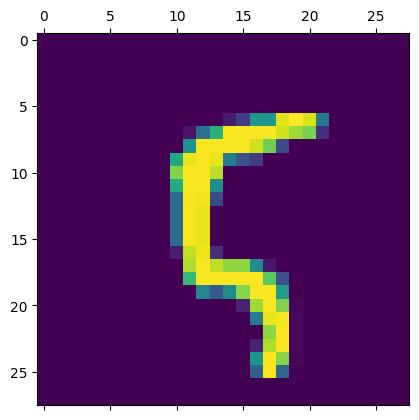

In [72]:
plt.matshow(x_train[100])


### **Flattern the 2D array : -**

In [73]:
x_train_flat = x_train.reshape(len(x_train),28*28)
x_test_flat = x_test.reshape(len(x_test),28*28)

In [74]:
x_train_flat.shape
x_test_flat.shape

(10000, 784)

In [75]:
x_train_flat[0]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,  18,  18,
       126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 17

In [76]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [77]:
model = keras.Sequential([
    keras.layers.Dense(10,input_shape=(784,), activation = 'sigmoid')
    
])

model.compile(optimizer = 'adam',
              loss = 'sparse_categorical_crossentropy',
              metrics = ['accuracy']
              )
model.fit(x_train_flat,y_train,epochs = 5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 384us/step - accuracy: 0.7774 - loss: 16.6382
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 383us/step - accuracy: 0.8780 - loss: 6.2227
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 383us/step - accuracy: 0.8843 - loss: 5.6164
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 394us/step - accuracy: 0.8876 - loss: 5.3936
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 382us/step - accuracy: 0.8894 - loss: 5.3051


In [78]:
model.evaluate(x_test_flat,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 381us/step - accuracy: 0.8323 - loss: 8.2893


[7.488368034362793, 0.8460999727249146]

In [79]:
y_predicted = model.predict(x_test_flat)
y_predicted

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 248us/step


array([[3.6855281e-35, 0.0000000e+00, 1.1094527e-37, ..., 1.0000000e+00,
        9.9999720e-01, 1.0000000e+00],
       [1.0000000e+00, 1.0000000e+00, 1.0000000e+00, ..., 0.0000000e+00,
        1.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 1.0000000e+00, 1.0000000e+00, ..., 1.0000000e+00,
        1.0000000e+00, 9.9999994e-01],
       ...,
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 1.0000000e+00,
        1.0000000e+00, 1.0000000e+00],
       [0.0000000e+00, 3.3742464e-21, 0.0000000e+00, ..., 7.2237541e-38,
        1.0000000e+00, 6.6138849e-38],
       [3.8765214e-02, 0.0000000e+00, 1.0000000e+00, ..., 0.0000000e+00,
        1.0000000e+00, 0.0000000e+00]], dtype=float32)

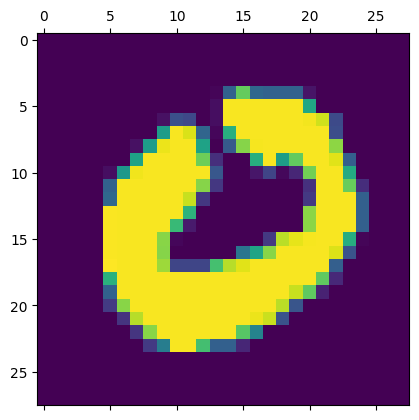

In [80]:
plt.matshow(x_test[25])

In [81]:
y_predicted[25]

array([1.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 1.0000000e+00, 1.0000000e+00, 0.0000000e+00,
       1.0000000e+00, 1.0352984e-32], dtype=float32)

In [82]:
print(np.argmax(y_predicted[25]))

0


# **Confusion matrix: -**

In [83]:
y_predicted_label = [np.argmax(i)for i in y_predicted]
y_predicted_label

[np.int64(3),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(4),
 np.int64(1),
 np.int64(3),
 np.int64(5),
 np.int64(0),
 np.int64(4),
 np.int64(0),
 np.int64(2),
 np.int64(3),
 np.int64(0),
 np.int64(1),
 np.int64(3),
 np.int64(4),
 np.int64(3),
 np.int64(2),
 np.int64(4),
 np.int64(3),
 np.int64(2),
 np.int64(2),
 np.int64(4),
 np.int64(4),
 np.int64(0),
 np.int64(3),
 np.int64(4),
 np.int64(0),
 np.int64(1),
 np.int64(3),
 np.int64(1),
 np.int64(3),
 np.int64(0),
 np.int64(3),
 np.int64(0),
 np.int64(2),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(3),
 np.int64(3),
 np.int64(0),
 np.int64(2),
 np.int64(3),
 np.int64(1),
 np.int64(1),
 np.int64(4),
 np.int64(4),
 np.int64(0),
 np.int64(2),
 np.int64(0),
 np.int64(3),
 np.int64(0),
 np.int64(0),
 np.int64(4),
 np.int64(1),
 np.int64(4),
 np.int64(5),
 np.int64(3),
 np.int64(2),
 np.int64(4),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(2),
 np.int64(0),
 np.int64(3),
 np.int64(0),
 np.int64(0),
 np.in

In [84]:
cm = tf.math.confusion_matrix(labels = y_test,predictions = y_predicted_label)
cm

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 976,    0,    1,    0,    0,    2,    1,    0,    0,    0],
       [   8, 1122,    5,    0,    0,    0,    0,    0,    0,    0],
       [ 392,  260,  371,    5,    2,    0,    1,    1,    0,    0],
       [ 187,  117,  346,  354,    1,    5,    0,    0,    0,    0],
       [ 101,   25,   70,  131,  655,    0,    0,    0,    0,    0],
       [ 213,   28,   70,  303,  105,  173,    0,    0,    0,    0],
       [ 291,   17,  569,   23,   29,   19,    9,    0,    1,    0],
       [  63,   48,  158,  540,   75,   84,    0,   60,    0,    0],
       [ 156,  130,  266,  269,   69,   83,    0,    0,    1,    0],
       [  49,   30,   28,  421,  448,   18,    0,   13,    1,    1]],
      dtype=int32)>

Text(95.72222222222221, 0.5, 'Actual')

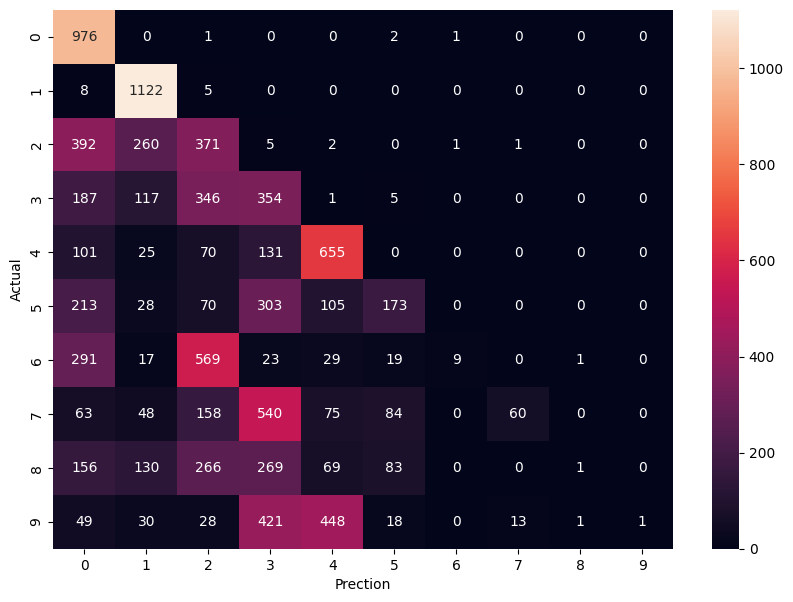

In [85]:
plt.figure(figsize = (10,7))
sns.heatmap(cm,annot = True,fmt = 'd')
plt.xlabel('Prection')
plt.ylabel('Actual')


# **Hidden layer : -**

In [86]:
x_train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [87]:

# Assuming y_train contains integer class labels
# y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)


In [88]:
model = keras.Sequential([
    keras.layers.Dense(100,input_shape=(784,), activation = 'elu'),
    keras.layers.Dense(50,input_shape=(100,), activation = 'swish'),
    keras.layers.Dense(10,activation = 'softmax')
    
])
model.compile(optimizer = 'adam',
              loss = 'Dice',
              metrics = ['accuracy']
              )
model.fit(x_train_flat,y_train,epochs = 7)

Epoch 1/7


/Users/yuvrajbhatkariya/data/VScode.C++/Python/myenv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


ValueError: Dimensions must be equal, but are 32 and 10 for '{{node compile_loss/dice/mul}} = Mul[T=DT_FLOAT](compile_loss/dice/Cast, sequential_11_1/dense_29_1/Softmax)' with input shapes: [32], [32,10].

In [49]:
model.evaluate(x_test_flat,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 501us/step - accuracy: 0.9516 - loss: 0.1809


[0.16147761046886444, 0.9573000073432922]